In [1]:
%matplotlib inline

# Notebook 2 of 3 -- Project Walkthrough, Part 1: Replicating a low-traffic SaaS growth-experiment stack and auditing the founder's current practice

**The synthetic results below are not production experience** -- they exist to make every claim in this walkthrough checkable against a known ground truth, not to be quoted to a client as real outcomes.

## Why this notebook exists

The Upwork brief (`research/job-posting.md`) is for an "AI Growth Engineer" role at a small B2B SaaS (2-9 people, history pointing at SEO tooling for a redirect/URL-migration product). The client wants the loop **idea -> working experiment -> real users -> data**, explicitly: landing-page conversion tests, free tools, programmatic SEO, onboarding/activation experiments, AI workflows, and "basic analytics & conversion funnels."

Three papers (re-read via `tools/reread.py`, never re-summarized from memory) form one story for that loop:

- **Measure** -- Lindon, Ham, Tingley, Bojinov, *Anytime-Valid Inference in Linear Models and Regression-Adjusted Causal Inference*, arXiv:2210.08589. Model-based / super-population (q1).
- **Iterate** -- Liang, Bojinov, *An Experimental Design for Anytime-Valid Causal Inference on Multi-Armed Bandits* (MAD), arXiv:2311.05794. Design-based / finite-population -- Liang & Bojinov state the population's potential outcomes are "non-random, so Y_i is random only via the treatment assignments W_i" (q1).
- **Screen** -- Persson, Schultzberg, Ankargren, *Statistical Foundations of LLM-based A/B Testing: A Surrogacy Framework for Human Causal Inference*, arXiv:2606.17165. Model-based; an **identification** result under Surrogacy + Comparability, not a coverage or anytime-valid guarantee (q1, q7, q11).

Notebook 1 (built in parallel) does the math behind these three papers. **This notebook (NB2) replicates the client's system**: a synthetic SaaS with known latent truth standing in for a real analytics export, an honest assignment/tracking layer, and -- critically -- a simulation of the founder's *current, naive* practice (peek every day, stop at first p<0.05). Notebook 3 will apply the three papers' machinery on top of the functions and globals defined here, executing these cells verbatim as an API.

## Initial project idea (draft -- open to revision)

An experiment harness for a founder-led SaaS: a **tracked funnel** that is honest about what it undercounts, **honest assignment** (hash-bucketed, SRM-checked) instead of ad-hoc cookie flags, **decisions that survive daily peeking** instead of "stop the first day it looks good," and **AI-generated variants that are screened before they consume real traffic**. This notebook builds the first three pieces plus a smoke-tested AI variant generator; NB3 wires in the papers' statistical guarantees.

## Dataset rationale

There is no public visitor-level B2B SaaS experiment dataset with pre-experiment covariates and a known ground truth -- real analytics exports never tell you the *true* conversion probability, only what happened once. The public dataset the screening paper itself uses, the Upworthy Research Archive, is **"32,487 randomized headline A/B tests"** (q9) run on **Facebook news-feed traffic in 2013-2015** -- news headlines, not a B2B developer tool, and not this client's funnel shape at all. So this notebook builds a **synthetic SaaS with latent truth**: every visitor has a true conversion probability under every arm, which lets every audit below be *scored* against ground truth instead of eyeballed. The human running this project for real should swap in their own PostHog / GA4 / Segment export once they have one -- see the "Limitations and open engineering choices" list in section 6.


In [2]:
# NB3-REUSE
import numpy as np
import hashlib, json, os, re, math, time
import urllib.request, urllib.error
from pathlib import Path
from statistics import NormalDist

SEED = 20260917
NOTEBOOK_DIR = Path.cwd()
DATA_DIR = (NOTEBOOK_DIR / ".." / "data").resolve()
DATA_DIR.mkdir(parents=True, exist_ok=True)

PALETTE = {
    "control": "#4C72B0",
    "treatment": "#DD8452",
    "organic_seo": "#4C72B0",
    "pseo_page": "#55A868",
    "ai_answer_referral": "#C44E52",
    "direct": "#8172B2",
    "dev_community": "#937860",
    "paid": "#DA8BC3",
    "truth": "#333333",
    "tracked": "#4C72B0",
    "winner": "#55A868",
    "loser": "#C44E52",
    "inconclusive": "#CCB974",
    "naive_peek": "#C44E52",
    "single_look": "#55A868",
    "historical": "#4C72B0",
    "generated": "#DD8452",
}


In [3]:
# NB3-REUSE
# Pure helper functions shared across sections (derived here; no scipy/sklearn/pandas available).

def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def _norm_cdf(x):
    # Vectorized standard-normal CDF via the Abramowitz & Stegun 7.1.26 erf approximation
    # (numpy has no erf/erfc and statistics.NormalDist is scalar-only). Derived here.
    x = np.asarray(x, dtype=float)
    z = x / math.sqrt(2.0)
    az = np.abs(z)
    t = 1.0 / (1.0 + 0.3275911 * az)
    y = 1.0 - (((((1.061405429 * t - 1.453152027) * t) + 1.421413741) * t - 0.284496736) * t + 0.254829592) * t * np.exp(-az * az)
    erf = np.sign(z) * y
    return 0.5 * (1.0 + erf)

def _hash_unit(key):
    h = hashlib.sha256(key.encode("utf-8")).digest()[:8]
    return int.from_bytes(h, "big") / 2**64

def wilson_interval(k, n, z=1.96):
    # Derived here (standard Wilson score interval for a binomial proportion).
    if n == 0:
        return (0.0, 0.0, 0.0)
    phat = k / n
    denom = 1 + z**2 / n
    center = (phat + z**2 / (2 * n)) / denom
    half = (z * math.sqrt(phat * (1 - phat) / n + z**2 / (4 * n**2))) / denom
    return (phat, max(0.0, center - half), min(1.0, center + half))

def _parse_json_array(content):
    try:
        v = json.loads(content)
        if isinstance(v, list):
            return v
    except Exception:
        pass
    m = re.search(r"\[.*\]", content, re.S)
    if m:
        try:
            v = json.loads(m.group())
            if isinstance(v, list):
                return v
        except Exception:
            pass
    return None

def _pass(cond):
    return "PASS" if cond else "FAIL"


## 1. Synthetic SaaS traffic and funnel with known latent truth (derived here)

*Re-read before writing this: `tools/reread.py q11` -- small samples / binary outcomes / optional stopping. Confirms (q11) that Lindon et al. "does NOT explicitly model or simulate binary conversion-type outcomes" and Persson et al.'s Monte Carlo uses "medium sample sizes of n = 2,000 (1,000 per arm)" -- i.e. nothing in the three papers hands us a ready-made binary-outcome SaaS simulator, so the traffic model below is entirely **derived here**.*

**Product**: a redirect-management SaaS for developers and SEO teams ("fix broken links and migrations before they cost you rankings"). Every visitor below carries a *true* conversion probability under every experiment arm -- something no real analytics export can ever give us, which is exactly why this synthetic layer exists (see the dataset rationale in section 0).

Visitors arrive with day-of-week seasonality (weekends lower), a channel mix (`organic_seo`, `pseo_page`, `ai_answer_referral`, `direct`, `dev_community`, `paid`), an SMB-heavy company-size mix, and a latent intent score shifted by channel. Pre-experiment covariates (`prior_sessions_30d`, `visited_pricing_before`, `fit_score`) are correlated with that intent, standing in for what a real product-analytics platform would already know about a visitor before an experiment starts.

**Deliberately hard-to-define cases** are built in as latent-truth flags, not just noise:
(a) ~5% bots, forced to zero true conversion probability regardless of arm; a heuristic bot filter (used in section 2) catches ~70% of them and false-flags ~1% of humans;
(b) ~6% of realized signups are duplicate signups from the same company domain -- is that a "conversion"?;
(c) a small share of signups are existing customers opening a second workspace, not new business;
(d) activation happens on a delayed, right-skewed schedule with a real tail beyond 7 days, so whatever we call "activated" at any fixed analysis cutoff will under-count late converters.


In [4]:
# NB3-REUSE
CHANNELS = ["organic_seo", "pseo_page", "ai_answer_referral", "direct", "dev_community", "paid"]
CHANNEL_WEIGHTS = np.array([0.28, 0.22, 0.10, 0.18, 0.12, 0.10])
CHANNEL_INTENT_SHIFT = {
    "organic_seo": 0.15, "pseo_page": -0.05, "ai_answer_referral": 0.05,
    "direct": 0.35, "dev_community": 0.25, "paid": -0.20,
}
COMPANY_SIZES = ["solo", "smb", "mid", "enterprise"]
SIZE_WEIGHTS = np.array([0.20, 0.50, 0.22, 0.08])  # SMB-heavy
DOW_MULT = np.array([1.00, 1.00, 1.00, 1.00, 0.95, 0.65, 0.60])  # Mon..Sun visitor-count seasonality


def generate_visitors(n_days, daily_mean, seed):
    """Unit-level synthetic visitor population. Returns dict[str, np.ndarray], one row per visitor."""
    rng = np.random.default_rng(seed)
    day_chunks, dow_chunks = [], []
    for day in range(n_days):
        dow = day % 7
        lam = daily_mean * DOW_MULT[dow]
        n = int(rng.poisson(lam))
        day_chunks.append(np.full(n, day))
        dow_chunks.append(np.full(n, dow))
    day = np.concatenate(day_chunks)
    dow = np.concatenate(dow_chunks)
    n_total = len(day)

    visitor_id = np.array([f"v{seed}_{i:07d}" for i in range(n_total)])
    channel = rng.choice(CHANNELS, size=n_total, p=CHANNEL_WEIGHTS / CHANNEL_WEIGHTS.sum())
    company_size = rng.choice(COMPANY_SIZES, size=n_total, p=SIZE_WEIGHTS / SIZE_WEIGHTS.sum())

    intent_shift = np.array([CHANNEL_INTENT_SHIFT[c] for c in channel])
    latent_intent = rng.normal(0, 1, n_total) + intent_shift

    prior_sessions_30d = rng.poisson(np.clip(0.5 + 1.5 * np.clip(latent_intent, 0, None), 0.05, None))
    visited_pricing_before = rng.binomial(1, _sigmoid(latent_intent - 0.5))
    fit_score = np.clip(latent_intent + rng.normal(0, 0.6, n_total), -4, 4)

    is_bot = rng.random(n_total) < 0.05
    enterprise_or_mid = np.isin(company_size, ["mid", "enterprise"])
    is_existing_customer = (rng.random(n_total) < 0.03) & (enterprise_or_mid | (rng.random(n_total) < 0.3))

    return dict(
        visitor_id=visitor_id, day=day, dow=dow, channel=channel, company_size=company_size,
        latent_intent=latent_intent, prior_sessions_30d=prior_sessions_30d,
        visited_pricing_before=visited_pricing_before, fit_score=fit_score,
        is_bot=is_bot, is_existing_customer=is_existing_customer,
    )


In [5]:
# NB3-REUSE
BASE_SIGNUP_INTERCEPT = -3.45          # calibrated so control humans convert at ~4% (see [S1.1] below)
SIGNUP_INTENT_COEF = 0.55
SIGNUP_CHANNEL_EFFECT = {
    "organic_seo": 0.10, "pseo_page": 0.00, "ai_answer_referral": -0.05,
    "direct": 0.30, "dev_community": 0.15, "paid": -0.25,
}
SIGNUP_SIZE_EFFECT = {"solo": -0.10, "smb": 0.10, "mid": 0.05, "enterprise": -0.20}
SIGNUP_DOW_EFFECT = np.array([0.00, 0.02, 0.02, 0.00, -0.05, -0.15, -0.15])
ACT_BASE_RATE = 0.40   # ~40% activate within the fast-tail component, given signup

ARM_SPECS = {
    "control": {"signup_rel_lift": 0.0, "activation_rel_lift": 0.0},
}


def _apply_rel_lift(p, rel_lift):
    # Exact relative-risk multiplier on the PROBABILITY scale: p' = clip(p * (1 + rel_lift), 0, 1).
    # Derived here. This is deliberately NOT a logit-scale shift -- log(1+rel) added to a logit is an
    # odds-ratio multiplier, which is only approximately equal to a relative-probability lift when the
    # baseline probability is small, and drifts further away from it as the base rate grows (e.g. at
    # ACT_BASE_RATE=0.40 a "+15%" logit-scale shift is actually only an +8.5% probability lift). ARM_SPECS
    # lifts are defined as exact relative lifts in probability, so this is the operation that must match
    # them. `headline_true_logit_lift` in section 5 is a separate, genuinely logit-scale latent-truth
    # function and is unaffected by this choice.
    return np.clip(np.asarray(p, dtype=float) * (1.0 + rel_lift), 0.0, 1.0)


def _base_signup_logit(visitors):
    ch = np.array([SIGNUP_CHANNEL_EFFECT[c] for c in visitors["channel"]])
    sz = np.array([SIGNUP_SIZE_EFFECT[s] for s in visitors["company_size"]])
    dow = SIGNUP_DOW_EFFECT[visitors["dow"]]
    return BASE_SIGNUP_INTERCEPT + SIGNUP_INTENT_COEF * visitors["latent_intent"] + ch + sz + dow


def simulate_outcomes(visitors, arm_of_visitor, arm_specs, seed):
    """Realized AND potential outcomes (signup, activation, activation delay) under every arm in
    arm_specs, so the true ATE is always computable, plus the definition-hard-case flags from section 1."""
    rng = np.random.default_rng(seed + 1)
    n = len(visitors["visitor_id"])
    base_signup_logit = _base_signup_logit(visitors)
    p_signup_base = _sigmoid(base_signup_logit)   # each visitor's control-arm signup probability
    arm_names = list(arm_specs.keys())

    # Shared uniform draws across arms -> potential outcomes are comparable draw-for-draw (same latent "coin").
    u_signup = rng.random(n)
    u_activation = rng.random(n)
    u_delay_branch = rng.random(n)
    u_delay_val = rng.random(n)

    signup_potential, activation_potential, delay_potential = {}, {}, {}
    for arm in arm_names:
        spec = arm_specs[arm]
        p_signup = _apply_rel_lift(p_signup_base, spec["signup_rel_lift"])
        p_signup = np.where(visitors["is_bot"], 0.0, p_signup)   # (a) bots: zero true conversion
        signup = u_signup < p_signup

        p_activation_scalar = _apply_rel_lift(ACT_BASE_RATE, spec["activation_rel_lift"])
        p_activation = np.full(n, float(p_activation_scalar))
        activation = signup & (u_activation < p_activation)

        # (d) activation delay: 85% fast (Exp, mean 2.5d), 15% slow (Uniform(5,20)d) -- a real tail past 7 days.
        fast = u_delay_branch < 0.85
        delay_fast = -2.5 * np.log(1 - u_delay_val)
        delay_slow = 5 + 15 * u_delay_val
        delay = np.where(fast, delay_fast, delay_slow)
        delay = np.where(activation, delay, np.nan)

        signup_potential[arm] = signup
        activation_potential[arm] = activation
        delay_potential[arm] = delay

    arm_arr = np.asarray(arm_of_visitor)
    signup_realized = np.zeros(n, dtype=bool)
    activation_realized = np.zeros(n, dtype=bool)
    delay_realized = np.full(n, np.nan)
    for arm in arm_names:
        mask = arm_arr == arm
        signup_realized[mask] = signup_potential[arm][mask]
        activation_realized[mask] = activation_potential[arm][mask]
        delay_realized[mask] = delay_potential[arm][mask]

    # (b), (c): hard cases layered on realized signups, derived here as independent flags rather than
    # a full company-domain collision model, for tractability.
    rng2 = np.random.default_rng(seed + 2)
    duplicate_domain_signup = signup_realized & (rng2.random(n) < 0.06)
    existing_customer_signup = signup_realized & visitors["is_existing_customer"]

    return dict(
        signup_potential=signup_potential, activation_potential=activation_potential,
        delay_potential=delay_potential,
        signup_realized=signup_realized, activation_realized=activation_realized,
        delay_realized=delay_realized,
        duplicate_domain_signup=duplicate_domain_signup,
        existing_customer_signup=existing_customer_signup,
    )


In [6]:
# Compute the section-1 population (all visitors on the single "control" arm -- this is the
# founder's product today, before any experiment is running).
visitors_s1 = generate_visitors(n_days=90, daily_mean=300, seed=SEED)
arm_of_visitor_s1 = np.full(len(visitors_s1["visitor_id"]), "control")
outcomes_s1 = simulate_outcomes(visitors_s1, arm_of_visitor_s1, {"control": ARM_SPECS["control"]}, seed=SEED)

n_total = len(visitors_s1["visitor_id"])
human_mask = ~visitors_s1["is_bot"]
bot_share = visitors_s1["is_bot"].mean()
control_signup_rate_humans = outcomes_s1["signup_realized"][human_mask].mean()

naive_signup_count = int(outcomes_s1["signup_realized"].sum())
true_new_signup_mask = (outcomes_s1["signup_realized"]
                         & ~outcomes_s1["duplicate_domain_signup"]
                         & ~outcomes_s1["existing_customer_signup"])
true_new_signup_count = int(true_new_signup_mask.sum())

dup_share_of_signups = outcomes_s1["duplicate_domain_signup"].sum() / max(1, naive_signup_count)
existing_share_of_signups = outcomes_s1["existing_customer_signup"].sum() / max(1, naive_signup_count)

activated = outcomes_s1["activation_realized"]
delay = outcomes_s1["delay_realized"]
tail_share = (delay[activated] > 7).mean()

print(f"n_total visitors           = {n_total}")
print(f"[S1.1] {_pass(0.030 <= control_signup_rate_humans <= 0.055)} control signup rate (humans) = {control_signup_rate_humans:.4f} (target band 3.0%-5.5%, design target ~4%)")
print(f"[S1.2] {_pass(0.035 <= bot_share <= 0.065)} bot share = {bot_share:.4f} (target band 3.5%-6.5%, design target ~5%)")
print(f"[S1.3] {_pass(0.03 <= dup_share_of_signups <= 0.09)} duplicate-domain share of realized signups = {dup_share_of_signups:.4f} (target band 3%-9%, design target ~6%)")
print(f"[S1.4] existing-customer share of realized signups = {existing_share_of_signups:.4f} (no hard band; flagged, not a bug)")
print(f"[S1.5] {_pass(0.08 <= tail_share <= 0.30)} activation-delay tail beyond 7 days (among activated) = {tail_share:.4f} (target band 8%-30%)")
print(f"[S1.6] {_pass(true_new_signup_count < naive_signup_count)} true new-signup count ({true_new_signup_count}) < naive raw signup count ({naive_signup_count}); "
      f"naive overstates by {(naive_signup_count/true_new_signup_count - 1)*100:.1f}%")


n_total visitors           = 24296
[S1.1] PASS control signup rate (humans) = 0.0414 (target band 3.0%-5.5%, design target ~4%)
[S1.2] PASS bot share = 0.0504 (target band 3.5%-6.5%, design target ~5%)
[S1.3] PASS duplicate-domain share of realized signups = 0.0577 (target band 3%-9%, design target ~6%)
[S1.4] existing-customer share of realized signups = 0.0157 (no hard band; flagged, not a bug)
[S1.5] PASS activation-delay tail beyond 7 days (among activated) = 0.1608 (target band 8%-30%)
[S1.6] PASS true new-signup count (885) < naive raw signup count (954); naive overstates by 7.8%


**How to read this chart.** Left panel: daily visitor volume by channel over the 90-day window, showing the weekend dip built into `DOW_MULT`. Right panel: the *true* signup rate by channel among humans (bots excluded, since their true conversion is 0 by construction) with a derived-here 95% Wilson interval per channel -- narrower channels (more traffic) get tighter bars; `direct` and `dev_community` should sit visibly above `paid`, matching the channel intent shifts coded above.

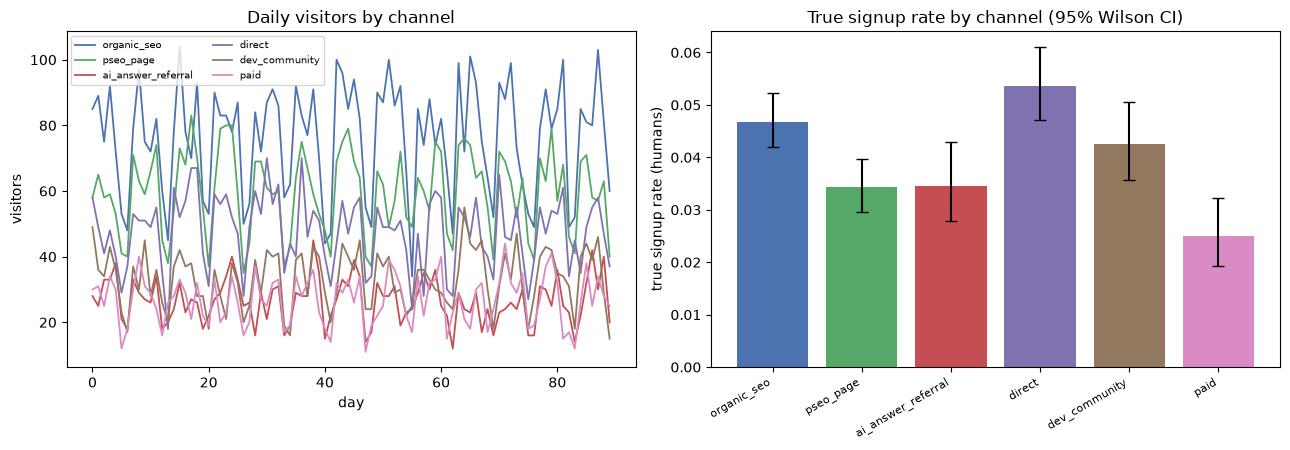

In [7]:
# Visualization only -- uses visitors_s1, outcomes_s1, human_mask, PALETTE, CHANNELS, wilson_interval
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ax = axes[0]
days = np.arange(visitors_s1["day"].max() + 1)
for ch in CHANNELS:
    counts = np.array([np.sum((visitors_s1["day"] == d) & (visitors_s1["channel"] == ch)) for d in days])
    ax.plot(days, counts, label=ch, color=PALETTE[ch], linewidth=1.3)
ax.set_xlabel("day"); ax.set_ylabel("visitors"); ax.set_title("Daily visitors by channel")
ax.legend(fontsize=7, ncol=2)

ax = axes[1]
rates, los, his = [], [], []
for ch in CHANNELS:
    mask = (visitors_s1["channel"] == ch) & human_mask
    k = int(outcomes_s1["signup_realized"][mask].sum())
    n = int(mask.sum())
    phat, lo, hi = wilson_interval(k, n)
    rates.append(phat); los.append(phat - lo); his.append(hi - phat)
xpos = np.arange(len(CHANNELS))
ax.bar(xpos, rates, yerr=[los, his], color=[PALETTE[c] for c in CHANNELS], capsize=4)
ax.set_xticks(xpos); ax.set_xticklabels(CHANNELS, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("true signup rate (humans)"); ax.set_title("True signup rate by channel (95% Wilson CI)")

fig.tight_layout()
plt.show()


## 2. Event tracking pipeline and what the dashboard would show (derived here)

*Re-read before writing this: `tools/reread.py q11`. Reconfirms nothing in the three papers models an event-tracking layer -- this whole section is derived here from how client-side/server-side analytics actually behave.*

Real analytics stacks mix client-side events (`page_view`, `tool_used` -- fired from the browser, dropped by ad blockers and privacy tooling) with server-side events (`signup_completed`, `first_redirect_created` -- fired from the backend, never dropped). We model ad-blocker loss at **25% for `dev_community`** traffic (a famously ad-blocker-heavy audience) and **10% everywhere else**, and we model a fixed **analysis cutoff** (`"today"` = the last day in the dataset) so that any visitor who signed up recently simply hasn't had time to activate yet -- the same right-censoring problem any dashboard queried "as of today" has.

The dashboard the founder actually looks at is built only from tracked events, not from latent truth. Comparing `build_funnel` on tracked events to the underlying truth is the audit.


In [8]:
# NB3-REUSE
AD_BLOCK_DROP_RATE = {"dev_community": 0.25}
DEFAULT_AD_BLOCK_DROP_RATE = 0.10


def emit_events(visitors, outcomes, analysis_cutoff_day, seed):
    """Client-side events are dropped (ad blockers); server-side events never are. Returns a flat
    dict of per-visitor event/flag arrays -- the 'tracked table' a real analytics pipeline would log,
    plus the latent-truth fields needed to audit it."""
    rng = np.random.default_rng(seed + 3)
    n = len(visitors["visitor_id"])
    drop_p = np.array([AD_BLOCK_DROP_RATE.get(c, DEFAULT_AD_BLOCK_DROP_RATE) for c in visitors["channel"]])

    page_view_tracked = rng.random(n) >= drop_p
    tool_used_tracked = page_view_tracked & (rng.random(n) >= drop_p)

    signup_completed = outcomes["signup_realized"].copy()        # server-side: never dropped
    signup_day = visitors["day"].copy()
    observed_activation_day = signup_day + outcomes["delay_realized"]
    first_redirect_created = outcomes["activation_realized"] & (observed_activation_day <= analysis_cutoff_day)

    return dict(
        visitor_id=visitors["visitor_id"], channel=visitors["channel"], day=visitors["day"],
        page_view_tracked=page_view_tracked, tool_used_tracked=tool_used_tracked,
        signup_completed=signup_completed, signup_day=signup_day,
        first_redirect_created=first_redirect_created,
        true_signup=outcomes["signup_realized"], true_activation=outcomes["activation_realized"],
        duplicate_domain_signup=outcomes["duplicate_domain_signup"],
        existing_customer_signup=outcomes["existing_customer_signup"],
        is_bot=visitors["is_bot"],
    )


def build_funnel(events):
    """The tracked table a dashboard would show, next to the latent-truth numbers for auditing."""
    tracked_visitors = int(events["page_view_tracked"].sum())
    tracked_signups = int(events["signup_completed"].sum())
    tracked_activations = int(events["first_redirect_created"].sum())
    true_visitors = int(len(events["visitor_id"]))
    true_new_signups = int((events["true_signup"]
                             & ~events["duplicate_domain_signup"]
                             & ~events["existing_customer_signup"]).sum())
    true_activations = int(events["true_activation"].sum())
    return dict(
        tracked_visitors=tracked_visitors, tracked_signups=tracked_signups,
        tracked_activations=tracked_activations,
        true_visitors=true_visitors, true_new_signups=true_new_signups, true_activations=true_activations,
    )


In [9]:
analysis_cutoff_day = int(visitors_s1["day"].max())
events_s1 = emit_events(visitors_s1, outcomes_s1, analysis_cutoff_day=analysis_cutoff_day, seed=SEED)
funnel_s1 = build_funnel(events_s1)

visitor_undercount_ratio = funnel_s1["tracked_visitors"] / funnel_s1["true_visitors"]
tracked_conv_rate = funnel_s1["tracked_signups"] / funnel_s1["tracked_visitors"]
true_conv_rate = funnel_s1["true_new_signups"] / funnel_s1["true_visitors"]
inflation_share = (events_s1["duplicate_domain_signup"] | events_s1["existing_customer_signup"]).sum() / max(1, funnel_s1["tracked_signups"])
activation_undercount_ratio = funnel_s1["tracked_activations"] / max(1, funnel_s1["true_activations"])

print("funnel_s1 (tracked vs truth):", funnel_s1)
print(f"[S2.1] {_pass(visitor_undercount_ratio < 0.96)} tracked visitors undercount true visitors: ratio = {visitor_undercount_ratio:.4f} (ad-blocker loss)")
print(f"[S2.2] {_pass(tracked_conv_rate > true_conv_rate)} tracked conversion rate ({tracked_conv_rate:.4f}) overstates true new-signup rate ({true_conv_rate:.4f}) -- "
      f"overstatement = {(tracked_conv_rate/true_conv_rate - 1)*100:.1f}%")
print(f"[S2.3] {_pass(inflation_share > 0.0)} duplicate/existing-customer share of tracked signups = {inflation_share:.4f}")
print(f"[S2.4] {_pass(activation_undercount_ratio < 1.0)} tracked activations undercount true activations at cutoff day {analysis_cutoff_day}: "
      f"tracked={funnel_s1['tracked_activations']}, true={funnel_s1['true_activations']}, ratio={activation_undercount_ratio:.4f} (right-censoring)")


funnel_s1 (tracked vs truth): {'tracked_visitors': 21378, 'tracked_signups': 954, 'tracked_activations': 348, 'true_visitors': 24296, 'true_new_signups': 885, 'true_activations': 367}
[S2.1] PASS tracked visitors undercount true visitors: ratio = 0.8799 (ad-blocker loss)
[S2.2] PASS tracked conversion rate (0.0446) overstates true new-signup rate (0.0364) -- overstatement = 22.5%
[S2.3] PASS duplicate/existing-customer share of tracked signups = 0.0723
[S2.4] PASS tracked activations undercount true activations at cutoff day 89: tracked=348, true=367, ratio=0.9482 (right-censoring)


**How to read this chart.** Three grouped bars -- visitors, signups, activations -- each showing the *tracked* (dashboard) count next to the *true* (latent) count. Visitors: tracked bar is shorter (ad-blocker loss). Signups: tracked bar is actually *not* shorter than the true new-signup bar -- it is inflated by duplicates/existing customers on top of a smaller undercounted-visitor denominator, which is exactly why the tracked *conversion rate* overstates the true one even though the raw signup count itself isn't a clean superset/subset relationship. Activations: tracked bar is much shorter than true, because the analysis cutoff censors recent, not-yet-activated signups.

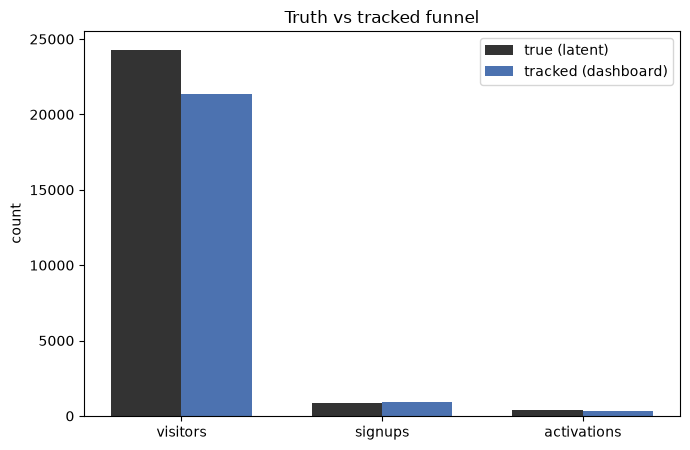

In [10]:
# Visualization only -- uses funnel_s1, PALETTE
import matplotlib.pyplot as plt

labels = ["visitors", "signups", "activations"]
tracked_vals = [funnel_s1["tracked_visitors"], funnel_s1["tracked_signups"], funnel_s1["tracked_activations"]]
true_vals = [funnel_s1["true_visitors"], funnel_s1["true_new_signups"], funnel_s1["true_activations"]]

x = np.arange(len(labels)); w = 0.35
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.bar(x - w/2, true_vals, width=w, label="true (latent)", color=PALETTE["truth"])
ax.bar(x + w/2, tracked_vals, width=w, label="tracked (dashboard)", color=PALETTE["tracked"])
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("count"); ax.set_title("Truth vs tracked funnel")
ax.legend()
fig.tight_layout()
plt.show()


## 3. Assignment and sample-ratio-mismatch checks (q3, q5; hashing and SRM derived here)

*Re-read before writing this: `tools/reread.py q3 q5`.*

Lindon et al.'s regression-adjusted causal inference result (Lemma 6.1, Section 6) needs a treatment indicator **"T_i ~ Bernoulli(rho) is a treatment indicator with assignment probability rho"** and states the covariates and treatment enter as `w_i = (1, (m_i - mu_m)', T_i - rho, T_i(m_i - mu_m)')'` (q3) -- i.e. assignment must actually *be* i.i.d. Bernoulli(rho), independent of covariates, or the regression-adjustment machinery is invalid. Liang & Bojinov's MAD estimator is even more assignment-probability-sensitive: the per-unit IPW estimator is **`tau_hat_i := 1{W_i=1} Y_i / p_i^MAD(1) - 1{W_i=0} Y_i / p_i^MAD(0)`** (q5, Eq. 1) -- the realized assignment probability `p_t^MAD(w)` enters the estimator directly, so if the assignment log doesn't record the exact probability each unit was assigned under, the estimator cannot even be computed, let alone be valid. Both papers are reasons an assignment layer needs to be deterministic, auditable, and probability-logging -- hashing does that; a cookie flag set client-side does not.

Hash bucketing and the sample-ratio-mismatch (SRM) check below are **derived here** -- neither paper specifies an assignment mechanism or an SRM diagnostic.


In [11]:
# NB3-REUSE
def assign(visitor_ids, experiment_key, weights):
    """Deterministic hash-bucket assignment: SHA-256(experiment_key + ':' + visitor_id) -> first 8
    bytes as uint64 / 2**64 -> bucket by cumulative weights. Same id + same key always -> same arm."""
    names = list(weights.keys())
    w = np.array([weights[n] for n in names], dtype=float)
    w = w / w.sum()
    cum = np.cumsum(w)
    u = np.array([_hash_unit(f"{experiment_key}:{vid}") for vid in visitor_ids])
    idx = np.searchsorted(cum, u, side="right")
    idx = np.clip(idx, 0, len(names) - 1)
    return np.array([names[i] for i in idx])


def srm_check(counts, weights):
    """Chi-square sample-ratio-mismatch test; p-value via the Wilson-Hilferty normal approximation
    to the chi-square distribution (derived here, since scipy is unavailable)."""
    names = list(weights.keys())
    obs = np.array([counts[n] for n in names], dtype=float)
    n_total = obs.sum()
    w = np.array([weights[n] for n in names], dtype=float)
    w = w / w.sum()
    exp = n_total * w
    chi2 = float(np.sum((obs - exp) ** 2 / exp))
    df = len(names) - 1
    if df <= 0:
        return {"chi2": chi2, "df": df, "p_value": 1.0}
    h = (chi2 / df) ** (1.0 / 3.0)
    mean_term = 1 - 2 / (9 * df)
    sd_term = math.sqrt(2 / (9 * df))
    z = (h - mean_term) / sd_term
    p_value = 1.0 - NormalDist().cdf(z)
    return {"chi2": chi2, "df": df, "p_value": p_value, "z": z}


In [12]:
# [S3.1] Uniformity: 200k synthetic ids, single experiment, check bucket shares within 3 SE of target.
ids_200k = np.array([f"u{i:07d}" for i in range(200_000)])
weights_5050 = {"control": 0.5, "treatment": 0.5}
arm_200k = assign(ids_200k, "srm_uniformity_demo", weights_5050)
n_ctrl = int((arm_200k == "control").sum())
share_ctrl = n_ctrl / len(ids_200k)
se_5050 = math.sqrt(0.5 * 0.5 / len(ids_200k))
print(f"[S3.1] {_pass(abs(share_ctrl - 0.5) <= 3*se_5050)} uniformity over 200k ids: control share = {share_ctrl:.5f}, "
      f"target 0.5 +/- 3SE = {3*se_5050:.5f}")

# [S3.2] Independence of two experiment keys: cross-tab close to product of margins.
arm_A = assign(ids_200k, "exp_A", weights_5050)
arm_B = assign(ids_200k, "exp_B", weights_5050)
cross = {}
for a in ["control", "treatment"]:
    for b in ["control", "treatment"]:
        observed = np.mean((arm_A == a) & (arm_B == b))
        expected = np.mean(arm_A == a) * np.mean(arm_B == b)
        cross[(a, b)] = (observed, expected)
max_gap = max(abs(o - e) for (o, e) in cross.values())
print(f"[S3.2] {_pass(max_gap < 0.01)} independence of exp_A x exp_B: max |observed - expected| over the 2x2 cross-tab = {max_gap:.5f}")
for k, (o, e) in cross.items():
    print(f"        {k}: observed={o:.5f} expected(product of margins)={e:.5f}")

# [S3.3] Covariate balance: assign the real section-1 population to an experiment and check SMDs.
arm_balance = assign(visitors_s1["visitor_id"], "e1_headline", weights_5050)
t_mask = arm_balance == "treatment"; c_mask = arm_balance == "control"
def _smd(x, t_mask, c_mask):
    xt, xc = x[t_mask], x[c_mask]
    pooled_sd = math.sqrt((xt.var(ddof=1) + xc.var(ddof=1)) / 2)
    return 0.0 if pooled_sd == 0 else abs(xt.mean() - xc.mean()) / pooled_sd
smd_prior_sessions = _smd(visitors_s1["prior_sessions_30d"].astype(float), t_mask, c_mask)
smd_fit_score = _smd(visitors_s1["fit_score"], t_mask, c_mask)
print(f"[S3.3] {_pass(smd_prior_sessions < 0.05 and smd_fit_score < 0.05)} covariate balance: "
      f"SMD(prior_sessions_30d)={smd_prior_sessions:.4f}, SMD(fit_score)={smd_fit_score:.4f} (target < 0.05 each)")


[S3.1] PASS uniformity over 200k ids: control share = 0.50138, target 0.5 +/- 3SE = 0.00335
[S3.2] PASS independence of exp_A x exp_B: max |observed - expected| over the 2x2 cross-tab = 0.00022
        ('control', 'control'): observed=0.24983 expected(product of margins)=0.24961
        ('control', 'treatment'): observed=0.25022 expected(product of margins)=0.25044
        ('treatment', 'control'): observed=0.24935 expected(product of margins)=0.24957
        ('treatment', 'treatment'): observed=0.25060 expected(product of margins)=0.25038
[S3.3] PASS covariate balance: SMD(prior_sessions_30d)=0.0054, SMD(fit_score)=0.0001 (target < 0.05 each)


In [13]:
# [S3.4] Detected SRM demo: TRUE assignment is 50/50, but the "exposure" event used to log an
# experiment is client-side and is dropped 10 points MORE often for treatment than control
# (e.g. a buggy exposure-logging snippet that fires later on the treatment variant's page).
arm_srm = assign(visitors_s1["visitor_id"], "srm_demo", weights_5050)
rng_srm = np.random.default_rng(SEED + 777)
drop_p_srm = np.where(arm_srm == "treatment", 0.20, 0.10)
exposure_tracked = rng_srm.random(len(arm_srm)) >= drop_p_srm

true_counts = {"control": int((arm_srm == "control").sum()), "treatment": int((arm_srm == "treatment").sum())}
tracked_counts = {
    "control": int(((arm_srm == "control") & exposure_tracked).sum()),
    "treatment": int(((arm_srm == "treatment") & exposure_tracked).sum()),
}
srm_true = srm_check(true_counts, weights_5050)
srm_tracked = srm_check(tracked_counts, weights_5050)
print(f"true assignment counts:    {true_counts}  -> srm_check: chi2={srm_true['chi2']:.3f}, p={srm_true['p_value']:.4f}")
print(f"tracked exposure counts:   {tracked_counts}  -> srm_check: chi2={srm_tracked['chi2']:.3f}, p={srm_tracked['p_value']:.4f}")
print(f"[S3.5] {_pass(srm_true['p_value'] > 0.05)} true assignment shows NO SRM (p > 0.05, as it should since assign() is honest)")
print(f"[S3.6] {_pass(srm_tracked['p_value'] < 0.01)} tracked exposure counts DO show SRM (p < 0.01) -- the client-side exposure "
      f"event is not a safe substitute for the assignment log; this is exactly why Lindon et al.'s T_i ~ Bernoulli(rho) (q3) and "
      f"MAD's p_t^MAD(w) entering the estimator directly (q5) both require the *assignment*, not a lossy proxy event, to be logged.")


true assignment counts:    {'control': 12226, 'treatment': 12070}  -> srm_check: chi2=1.002, p=0.3183
tracked exposure counts:   {'control': 10973, 'treatment': 9600}  -> srm_check: chi2=91.631, p=0.0000
[S3.5] PASS true assignment shows NO SRM (p > 0.05, as it should since assign() is honest)
[S3.6] PASS tracked exposure counts DO show SRM (p < 0.01) -- the client-side exposure event is not a safe substitute for the assignment log; this is exactly why Lindon et al.'s T_i ~ Bernoulli(rho) (q3) and MAD's p_t^MAD(w) entering the estimator directly (q5) both require the *assignment*, not a lossy proxy event, to be logged.


**How to read this chart.** Left: the 200k-id uniformity check as observed vs expected bucket shares with a 3-SE band -- bars should sit on the dashed target line. Right: the SRM demo -- true assignment counts (from `assign()`) are balanced, but counts built from the lossy client-side "exposure" event are visibly skewed toward control, which is what triggers `srm_check`'s low p-value.

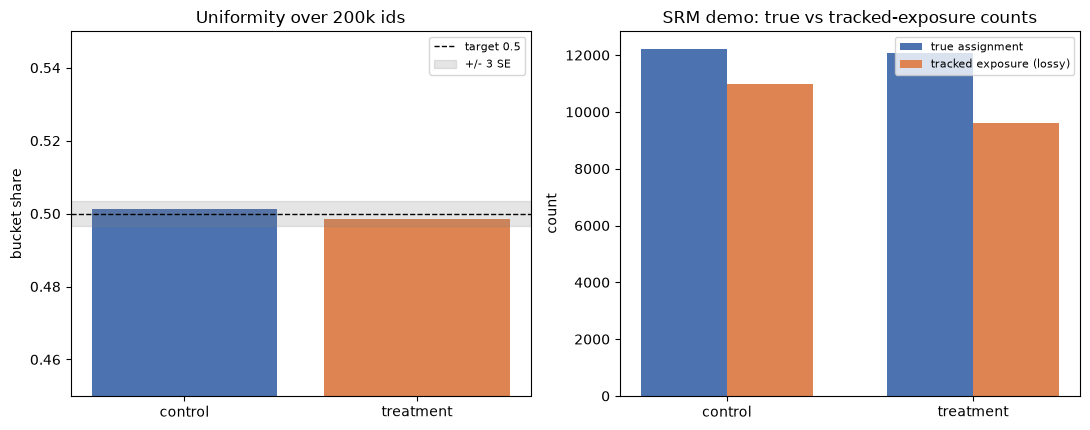

In [14]:
# Visualization only -- uses share_ctrl, se_5050, true_counts, tracked_counts, PALETTE
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

ax = axes[0]
ax.bar(["control", "treatment"], [share_ctrl, 1 - share_ctrl], color=[PALETTE["control"], PALETTE["treatment"]])
ax.axhline(0.5, color="black", linestyle="--", linewidth=1, label="target 0.5")
ax.axhspan(0.5 - 3*se_5050, 0.5 + 3*se_5050, color="grey", alpha=0.2, label="+/- 3 SE")
ax.set_ylim(0.45, 0.55); ax.set_ylabel("bucket share"); ax.set_title("Uniformity over 200k ids"); ax.legend(fontsize=8)

ax = axes[1]
x = np.arange(2); w = 0.35
ax.bar(x - w/2, [true_counts["control"], true_counts["treatment"]], width=w, label="true assignment", color=PALETTE["control"])
ax.bar(x + w/2, [tracked_counts["control"], tracked_counts["treatment"]], width=w, label="tracked exposure (lossy)", color=PALETTE["treatment"])
ax.set_xticks(x); ax.set_xticklabels(["control", "treatment"])
ax.set_ylabel("count"); ax.set_title("SRM demo: true vs tracked-exposure counts"); ax.legend(fontsize=8)

fig.tight_layout()
plt.show()


## 4. The founder's current practice: a baseline audit (q4, q11; the peeking policy is derived here)

*Re-read before writing this: `tools/reread.py q4 q11`.*

The founder's actual current process (not from any paper -- **derived here** as the thing we're about to audit): run a **two-proportion z-test on signups, computed every day, stop and ship at the first day p < 0.05; otherwise stop and call it a loss at day 28.** No paper prescribes this; it is the practice this notebook exists to audit. We run four experiments against it:

- **E1** -- new landing headline, true **+8% relative signup lift**.
- **E2** -- an A/A test (no true effect on anything): measures the false-positive rate of the naive policy itself.
- **E3** -- onboarding checklist: **0 true signup effect**, but **+15% relative activation lift**. A naive policy that only ever looks at signups can only see this experiment as noise.
- **E4** -- a "clickbait" headline: **+10% relative signup lift** but **-20% relative activation lift** -- net activated users go *down* even though signups go up.

Each Monte Carlo replication aggregates daily `Binomial` signup counts at the true per-arm rate (**derived-here shortcut, stated explicitly**: this avoids re-simulating the full unit-level population thousands of times) at **~150 visitors/arm/day**, for 28 days, across >=500 replications. We separately run **one full unit-level realization** with `generate_visitors`/`simulate_outcomes`/`assign` for the plotted example, so the naive z-test is also shown running on data that actually came out of the section-1/3 machinery, not just an abstract binomial stream.

Outcomes are classified **winner / loser / inconclusive** based on the sign and significance of the estimate at the naive policy's stopping day. **Inconclusive is not an error** -- stopping at day 28 without significance is exactly what a fixed, non-anytime-valid test is supposed to do sometimes.

For contrast, Lindon et al.'s own null-rejection numbers under continuous monitoring at alpha=0.01: a fixed-n test at n*=1785 rejects **"1.07% of nulls (matching alpha=0.01)"**, while their anytime-valid test rejects only **"0.04%"** (g_g) or **"0.03%"** (g_w) (q4) -- and under a real effect, **"the anytime-valid test with g_g=100 rejected 81.69% of nulls by n*=1785, with an average stopping time of 1,214.45"** versus **95.02%** power for the fixed-n test evaluated at that same n* (q4, q11). The naive daily-peeking policy below is neither of these -- it has neither the fixed-n test's clean alpha nor the anytime-valid test's time-uniform guarantee; it is closer to the "Gaussian confidence sequence... over-rejects severely at small sample sizes" failure mode Lindon et al. warn about (q4, q11), just without the delayed-start fix.


In [15]:
def _lift_prob(p0, rel_lift):
    # Exact relative-risk multiplier on the probability scale (same convention as _apply_rel_lift
    # in simulate_outcomes, so section 4's aggregated-binomial MC uses IDENTICAL true rates to what
    # a unit-level run with these ARM_SPECS would produce).
    return float(_apply_rel_lift(p0, rel_lift))


E1_P0, E1_P1 = 0.04, _lift_prob(0.04, 0.08)
E2_P0, E2_P1 = 0.04, 0.04
E3_P0, E3_P1 = 0.04, 0.04
E4_P0, E4_P1 = 0.04, _lift_prob(0.04, 0.10)
ACT_BASE = ACT_BASE_RATE
E1_ACT0, E1_ACT1 = ACT_BASE, ACT_BASE
E2_ACT0, E2_ACT1 = ACT_BASE, ACT_BASE
E3_ACT0, E3_ACT1 = ACT_BASE, _lift_prob(ACT_BASE, 0.15)
E4_ACT0, E4_ACT1 = ACT_BASE, _lift_prob(ACT_BASE, -0.20)

print(f"E1 true signup rates: {E1_P0} -> {E1_P1}, exact relative lift = {(E1_P1/E1_P0 - 1):.4f} (target 0.08)")
print(f"E3 true activation rates: {E3_ACT0} -> {E3_ACT1}, exact relative lift = {(E3_ACT1/E3_ACT0 - 1):.4f} (target 0.15)")
print(f"E4 true signup rates: {E4_P0} -> {E4_P1}, exact relative lift = {(E4_P1/E4_P0 - 1):.4f} (target 0.10)")
print(f"E4 true activation rates: {E4_ACT0} -> {E4_ACT1}, exact relative lift = {(E4_ACT1/E4_ACT0 - 1):.4f} (target -0.20)")

e4_true_activated_per_visitor_control = E4_P0 * E4_ACT0
e4_true_activated_per_visitor_treat = E4_P1 * E4_ACT1
e4_true_pct_change = (e4_true_activated_per_visitor_treat / e4_true_activated_per_visitor_control - 1) * 100
print(f"[S4.0] E4 TRUE activated-users-per-visitor (signup_rate x activation_rate): "
      f"control={e4_true_activated_per_visitor_control:.5f}, treatment={e4_true_activated_per_visitor_treat:.5f}, "
      f"true change = {e4_true_pct_change:.1f}% -- this is a fixed population-level fact, true for every replication, "
      f"not something that varies with sampling noise.")


def run_naive_mc(p_signup_control, p_signup_treat, p_activation_control, p_activation_treat,
                  n_per_arm_per_day=150, n_days=28, reps=2000, seed=0):
    """Monte Carlo of the founder's naive daily-peeking policy. Aggregated daily Binomial counts at
    the true arm rates (derived-here MC shortcut, stated explicitly -- not a unit-level simulation)."""
    rng = np.random.default_rng(seed)
    inc_c = rng.binomial(n_per_arm_per_day, p_signup_control, size=(reps, n_days))
    inc_t = rng.binomial(n_per_arm_per_day, p_signup_treat, size=(reps, n_days))
    cum_c = np.cumsum(inc_c, axis=1)
    cum_t = np.cumsum(inc_t, axis=1)
    n_c = n_per_arm_per_day * np.arange(1, n_days + 1)[None, :]
    n_t = n_c
    phat_c = cum_c / n_c
    phat_t = cum_t / n_t
    ppool = (cum_c + cum_t) / (n_c + n_t)
    se = np.sqrt(ppool * (1 - ppool) * (1 / n_c + 1 / n_t))
    with np.errstate(divide="ignore", invalid="ignore"):
        z = (phat_t - phat_c) / se
    z = np.nan_to_num(z, nan=0.0)
    pval = 2 * (1 - _norm_cdf(np.abs(z)))
    sig = pval < 0.05

    any_sig = sig.any(axis=1)
    first_sig = np.argmax(sig, axis=1)
    stop_idx = np.where(any_sig, first_sig, n_days - 1)
    rows = np.arange(reps)
    p_at_stop = pval[rows, stop_idx]
    diff_at_stop = (phat_t - phat_c)[rows, stop_idx]
    classify = np.where(p_at_stop >= 0.05, "inconclusive", np.where(diff_at_stop > 0, "winner", "loser"))

    cum_c_stop = cum_c[rows, stop_idx]
    cum_t_stop = cum_t[rows, stop_idx]
    rng2 = np.random.default_rng(seed + 1)
    act_c = rng2.binomial(cum_c_stop, p_activation_control)
    act_t = rng2.binomial(cum_t_stop, p_activation_treat)

    return dict(stop_idx=stop_idx, classify=classify, p_at_stop=p_at_stop, diff_at_stop=diff_at_stop,
                any_sig=any_sig, sig_matrix=sig, act_c=act_c, act_t=act_t,
                cum_c_stop=cum_c_stop, cum_t_stop=cum_t_stop)


N_REPS = 2000
res_E1 = run_naive_mc(E1_P0, E1_P1, E1_ACT0, E1_ACT1, reps=N_REPS, seed=SEED + 101)
res_E2 = run_naive_mc(E2_P0, E2_P1, E2_ACT0, E2_ACT1, reps=N_REPS, seed=SEED + 102)
res_E3 = run_naive_mc(E3_P0, E3_P1, E3_ACT0, E3_ACT1, reps=N_REPS, seed=SEED + 103)
res_E4 = run_naive_mc(E4_P0, E4_P1, E4_ACT0, E4_ACT1, reps=N_REPS, seed=SEED + 104)
print(f"Monte Carlo replications per experiment: {N_REPS} (>= 500 required)")


E1 true signup rates: 0.04 -> 0.0432, exact relative lift = 0.0800 (target 0.08)
E3 true activation rates: 0.4 -> 0.45999999999999996, exact relative lift = 0.1500 (target 0.15)
E4 true signup rates: 0.04 -> 0.044000000000000004, exact relative lift = 0.1000 (target 0.10)
E4 true activation rates: 0.4 -> 0.32000000000000006, exact relative lift = -0.2000 (target -0.20)
[S4.0] E4 TRUE activated-users-per-visitor (signup_rate x activation_rate): control=0.01600, treatment=0.01408, true change = -12.0% -- this is a fixed population-level fact, true for every replication, not something that varies with sampling noise.
Monte Carlo replications per experiment: 2000 (>= 500 required)


In [16]:
# E2: false-positive rate under daily peeking vs a single look at day 28.
e2_fpr_daily_peek = res_E2["any_sig"].mean()
e2_fpr_single_look = res_E2["sig_matrix"][:, -1].mean()
print(f"[S4.1] {_pass(e2_fpr_daily_peek > 0.05)} E2 false-positive rate, daily peeking = {e2_fpr_daily_peek:.4f} (inflated above nominal alpha=0.05)")
print(f"[S4.2] {_pass(abs(e2_fpr_single_look - 0.05) < 0.02)} E2 false-positive rate, single look at day 28 = {e2_fpr_single_look:.4f} (should track nominal alpha=0.05)")

# E1: share declared winner, median stopping day among winners.
e1_winner_share = (res_E1["classify"] == "winner").mean()
e1_loser_share = (res_E1["classify"] == "loser").mean()
e1_inconclusive_share = (res_E1["classify"] == "inconclusive").mean()
e1_winner_stop_days = res_E1["stop_idx"][res_E1["classify"] == "winner"] + 1
e1_median_stop_day = float(np.median(e1_winner_stop_days)) if len(e1_winner_stop_days) else float("nan")
e2_winner_share = (res_E2["classify"] == "winner").mean()   # E2's spurious "winner" rate under the true null
print(f"[S4.3] E1 (true +8% signup lift) outcome shares: winner={e1_winner_share:.3f}, loser={e1_loser_share:.3f}, inconclusive={e1_inconclusive_share:.3f}")
print(f"[S4.4] {_pass(e1_winner_share > e2_winner_share)} E1 winner share ({e1_winner_share:.3f}) exceeds E2's spurious winner "
      f"rate under the true null ({e2_winner_share:.3f}); median stopping day among E1's declared winners = {e1_median_stop_day:.1f} (of 28). "
      f"With only ~150 visitors/arm/day and a modest true lift, most replications end 'inconclusive' at day 28 rather than shipping "
      f"early -- an honest, not-alarming, result of a low-traffic experiment against a small effect.")

# E3: 0 true signup effect but +15% true activation effect -- "wrongly dropped" share.
e3_loser_share = (res_E3["classify"] == "loser").mean()
e3_winner_share = (res_E3["classify"] == "winner").mean()
print(f"[S4.5] E3 (0 true signup effect, +15% true activation effect) outcome shares: "
      f"winner={e3_winner_share:.3f}, loser={e3_loser_share:.3f}, inconclusive={1-e3_winner_share-e3_loser_share:.3f}")
print(f"[S4.6] {_pass(e3_loser_share > 0.0)} E3 wrongly-dropped share (declared loser on signups despite 0 true signup effect "
      f"and a real +15% activation gain that the naive policy never looks at) = {e3_loser_share:.4f}")

# E4: shipped as a signup winner while activations actually fall.
e4_winner_share = (res_E4["classify"] == "winner").mean()
e4_activation_fell = res_E4["act_t"] < res_E4["act_c"]
e4_winner_and_fell_share = ((res_E4["classify"] == "winner") & e4_activation_fell).mean()
e4_winner_and_fell_conditional = e4_winner_and_fell_share / max(1e-9, e4_winner_share)
print(f"[S4.7] E4 (true +10% signup lift, true -20% activation lift) winner share = {e4_winner_share:.3f}")
print(f"[S4.8] {_pass(e4_true_pct_change < 0)} EVERY E4 'winner' replication ({e4_winner_share*100:.1f}% of all reps) ships a "
      f"change that TRULY lowers activated users per visitor by {abs(e4_true_pct_change):.1f}% -- this is true by construction "
      f"for all of them, not a subset, because it is a fixed population-level fact (see [S4.0]). But only "
      f"{e4_winner_and_fell_conditional*100:.1f}% of those winners would even SHOW an activation fall (act_t < act_c) in their "
      f"own stopped sample -- i.e. a naive signups-only guardrail is badly under-powered to catch this at this traffic level, "
      f"not merely 'usually fine'.")


[S4.1] PASS E2 false-positive rate, daily peeking = 0.2840 (inflated above nominal alpha=0.05)
[S4.2] PASS E2 false-positive rate, single look at day 28 = 0.0455 (should track nominal alpha=0.05)
[S4.3] E1 (true +8% signup lift) outcome shares: winner=0.285, loser=0.070, inconclusive=0.645
[S4.4] PASS E1 winner share (0.285) exceeds E2's spurious winner rate under the true null (0.132); median stopping day among E1's declared winners = 7.0 (of 28). With only ~150 visitors/arm/day and a modest true lift, most replications end 'inconclusive' at day 28 rather than shipping early -- an honest, not-alarming, result of a low-traffic experiment against a small effect.
[S4.5] E3 (0 true signup effect, +15% true activation effect) outcome shares: winner=0.129, loser=0.138, inconclusive=0.733
[S4.6] PASS E3 wrongly-dropped share (declared loser on signups despite 0 true signup effect and a real +15% activation gain that the naive policy never looks at) = 0.1380
[S4.7] E4 (true +10% signup lift, 

In [17]:
# Fixed-horizon sample size for 80% power at alpha=0.05 for E1, and implied days at ~150 visitors/arm/day.
def sample_size_two_proportion(p0, p1, alpha=0.05, power=0.8):
    # Derived here (standard two-proportion power formula; not from the three papers).
    z_a2 = NormalDist().inv_cdf(1 - alpha / 2)
    z_b = NormalDist().inv_cdf(power)
    return ((z_a2 + z_b) ** 2 * (p0 * (1 - p0) + p1 * (1 - p1))) / (p1 - p0) ** 2

n_per_arm_fixed = sample_size_two_proportion(E1_P0, E1_P1, alpha=0.05, power=0.8)
implied_days_150 = math.ceil(n_per_arm_fixed / 150)
print(f"[S4.9] E1 fixed-horizon two-proportion sample size (alpha=0.05, power=80%): n_per_arm = {n_per_arm_fixed:.0f} "
      f"-> implied days at ~150 visitors/arm/day = {implied_days_150}")
print("       Contrast (q4): at n*=1785 (their own MDE-sized horizon) the fixed-n test achieves 95.02% power, "
      "while the anytime-valid test (g_g=100) achieves 81.69% power evaluated strictly at that n*, but with a mean "
      "stopping time of only 1214.45 when it does reject -- i.e. the anytime-valid procedure trades some power AT a "
      "fixed horizon for the ability to stop much earlier on average. Under the null it also rejects far less often "
      "than the fixed-n test peeked once (0.04% vs 1.07% at alpha=0.01, q4) -- the naive daily-peek policy audited "
      "here has neither property.")


[S4.9] E1 fixed-horizon two-proportion sample size (alpha=0.05, power=80%): n_per_arm = 61115 -> implied days at ~150 visitors/arm/day = 408
       Contrast (q4): at n*=1785 (their own MDE-sized horizon) the fixed-n test achieves 95.02% power, while the anytime-valid test (g_g=100) achieves 81.69% power evaluated strictly at that n*, but with a mean stopping time of only 1214.45 when it does reject -- i.e. the anytime-valid procedure trades some power AT a fixed horizon for the ability to stop much earlier on average. Under the null it also rejects far less often than the fixed-n test peeked once (0.04% vs 1.07% at alpha=0.01, q4) -- the naive daily-peek policy audited here has neither property.


In [18]:
# ONE unit-level realization of E1, using the section-1/3 machinery (generate_visitors, assign,
# simulate_outcomes), for the plotted example below -- not part of the aggregated Monte Carlo.
visitors_e1 = generate_visitors(n_days=28, daily_mean=300, seed=SEED + 900)
arm_e1_unit = assign(visitors_e1["visitor_id"], "e1_headline_unit_demo", weights_5050)
e1_arm_specs = {
    "control": {"signup_rel_lift": 0.0, "activation_rel_lift": 0.0},
    "treatment": {"signup_rel_lift": 0.08, "activation_rel_lift": 0.0},
}
outcomes_e1_unit = simulate_outcomes(visitors_e1, arm_e1_unit, e1_arm_specs, seed=SEED + 900)

c_mask_u = arm_e1_unit == "control"; t_mask_u = arm_e1_unit == "treatment"
days_u = np.arange(visitors_e1["day"].max() + 1)
cum_c_u, cum_t_u, n_c_u, n_t_u, pvals_u = [], [], [], [], []
for d in days_u:
    day_mask = visitors_e1["day"] <= d
    kc = int(outcomes_e1_unit["signup_realized"][c_mask_u & day_mask].sum())
    kt = int(outcomes_e1_unit["signup_realized"][t_mask_u & day_mask].sum())
    nc = int((c_mask_u & day_mask).sum()); nt = int((t_mask_u & day_mask).sum())
    cum_c_u.append(kc); cum_t_u.append(kt); n_c_u.append(nc); n_t_u.append(nt)
    pc, pt = kc / max(1, nc), kt / max(1, nt)
    ppool = (kc + kt) / max(1, nc + nt)
    se = math.sqrt(ppool * (1 - ppool) * (1 / max(1, nc) + 1 / max(1, nt))) if 0 < ppool < 1 else float("nan")
    z = (pt - pc) / se if se and se > 0 else 0.0
    pvals_u.append(2 * (1 - NormalDist().cdf(abs(z))) if se and se > 0 else 1.0)
pvals_u = np.array(pvals_u)
sig_days_u = np.where(pvals_u < 0.05)[0]
unit_stop_day = int(sig_days_u[0]) if len(sig_days_u) else int(days_u[-1])
print(f"[S4.10] unit-level E1 realization: stop day = {unit_stop_day+1} of 28, "
      f"p-value at stop = {pvals_u[unit_stop_day]:.4f}, "
      f"cumulative signup rate control={cum_c_u[unit_stop_day]/max(1,n_c_u[unit_stop_day]):.4f}, "
      f"treatment={cum_t_u[unit_stop_day]/max(1,n_t_u[unit_stop_day]):.4f} "
      f"(sanity check only, not part of the aggregated Monte Carlo above)")


[S4.10] unit-level E1 realization: stop day = 12 of 28, p-value at stop = 0.0472, cumulative signup rate control=0.0365, treatment=0.0503 (sanity check only, not part of the aggregated Monte Carlo above)


**How to read this chart.** Top-left: E2's cumulative false-positive rate as a function of day -- the "daily peek" line is the fraction of Monte Carlo replications that have *ever* crossed p<0.05 by day d (monotonically rising, ending well above 5%); the "single look" line is the fraction that would be significant if you only ever evaluated on day d itself (should hover near the nominal 5% line for every d, since each is a legitimate one-shot test). Top-right: outcome-class stacked bars (winner/loser/inconclusive) for all four experiments -- E3's loser slice is the "wrongly dropped" mistake. E1's (small but nonzero) loser slice is a genuine sign error induced by daily peeking: E1 has a truly positive effect, so any replication the naive policy classifies "loser" got there purely from noise crossing significance in the wrong direction before the signal accumulated -- a useful, honest finding about how peeking corrupts direction, not just significance. E4's winner slice is *entirely* composed of replications that truly lowered activated users per visitor (see [S4.0]/[S4.8]) -- only a minority of them would even show that fall in their own stopped sample, which is the real headline of E4, not that most winners are somehow safe. Bottom: the one unit-level E1 realization -- cumulative signup rate for control vs treatment day by day, with the naive policy's stopping day marked.

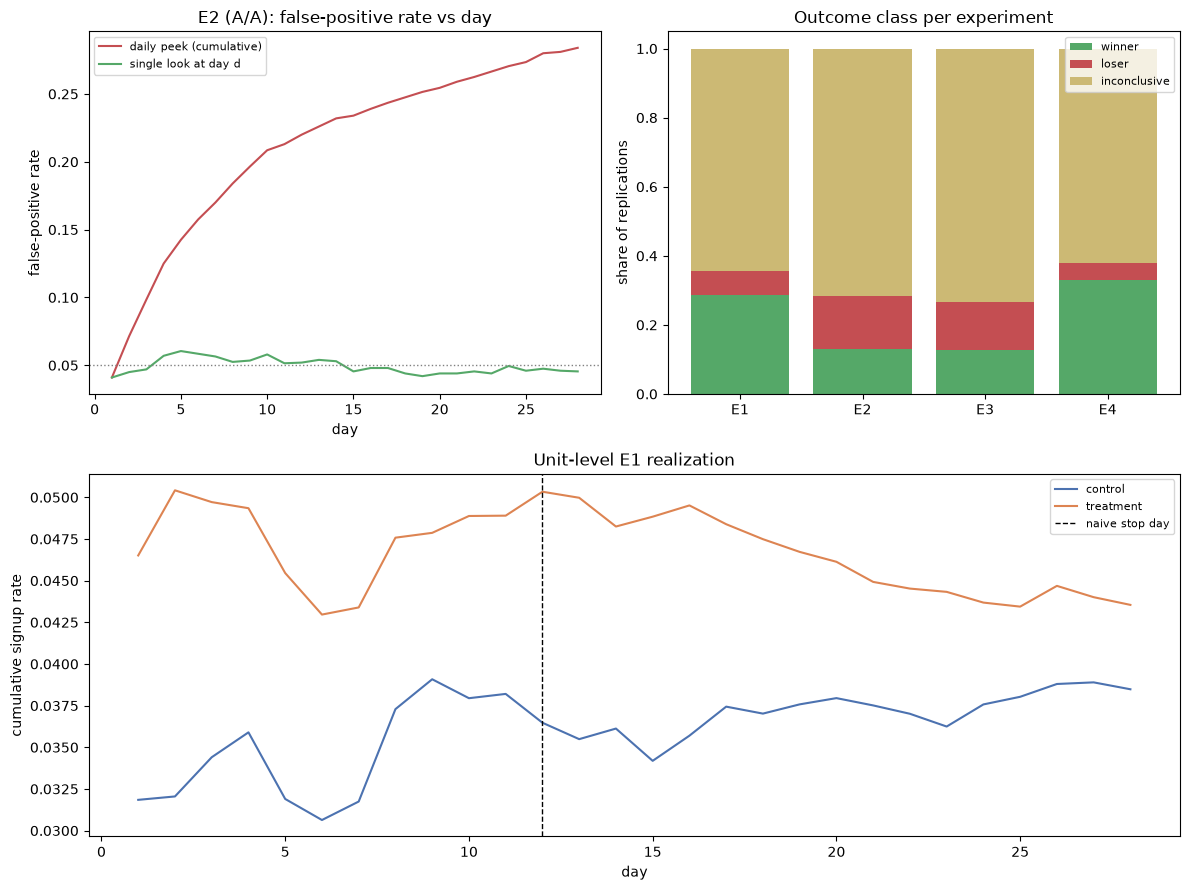

In [19]:
# Visualization only -- uses res_E2, res_E1..res_E4, cum_c_u, cum_t_u, n_c_u, n_t_u, unit_stop_day, PALETTE
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 9))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

ax = fig.add_subplot(gs[0, 0])
days28 = np.arange(1, 29)
peek_curve = np.cumsum(res_E2["sig_matrix"], axis=1) > 0
peek_curve = peek_curve.mean(axis=0)
single_curve = res_E2["sig_matrix"].mean(axis=0)
ax.plot(days28, peek_curve, label="daily peek (cumulative)", color=PALETTE["naive_peek"])
ax.plot(days28, single_curve, label="single look at day d", color=PALETTE["single_look"])
ax.axhline(0.05, color="grey", linestyle=":", linewidth=1)
ax.set_xlabel("day"); ax.set_ylabel("false-positive rate"); ax.set_title("E2 (A/A): false-positive rate vs day")
ax.legend(fontsize=8)

ax = fig.add_subplot(gs[0, 1])
exps = ["E1", "E2", "E3", "E4"]
results = [res_E1, res_E2, res_E3, res_E4]
winner_sh = [(r["classify"] == "winner").mean() for r in results]
loser_sh = [(r["classify"] == "loser").mean() for r in results]
inconclusive_sh = [(r["classify"] == "inconclusive").mean() for r in results]
x = np.arange(len(exps))
ax.bar(x, winner_sh, label="winner", color=PALETTE["winner"])
ax.bar(x, loser_sh, bottom=winner_sh, label="loser", color=PALETTE["loser"])
bottom2 = np.array(winner_sh) + np.array(loser_sh)
ax.bar(x, inconclusive_sh, bottom=bottom2, label="inconclusive", color=PALETTE["inconclusive"])
ax.set_xticks(x); ax.set_xticklabels(exps)
ax.set_ylabel("share of replications"); ax.set_title("Outcome class per experiment"); ax.legend(fontsize=8)

ax = fig.add_subplot(gs[1, :])
rate_c = np.array(cum_c_u) / np.maximum(1, np.array(n_c_u))
rate_t = np.array(cum_t_u) / np.maximum(1, np.array(n_t_u))
ax.plot(days_u + 1, rate_c, label="control", color=PALETTE["control"])
ax.plot(days_u + 1, rate_t, label="treatment", color=PALETTE["treatment"])
ax.axvline(unit_stop_day + 1, color="black", linestyle="--", linewidth=1, label="naive stop day")
ax.set_xlabel("day"); ax.set_ylabel("cumulative signup rate"); ax.set_title("Unit-level E1 realization")
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()


## 5. AI workflow: generating headline variants with DeepSeek (smoke test; q9, q10)

*Re-read before writing this: `tools/reread.py q9 q10`.*

Persson et al.'s screening pipeline is a specific, quotable three-step procedure: **"(1) Instruct the LLM to adopt characteristics given by X. (2) Let the LLM interact with the environment/scenario corresponding to its assigned condition (W=0 or W=1). (3) Record the outcome Y*, which is a draw from F(.|W,X)"** (q9, q10). Their CTR-prediction prompt is quoted verbatim in the traces: a system prompt that fixes the persona/scenario and asks for **"a single integer giving the predicted CTR in basis points"**, and a user prompt of the form `"Headline: {headline}\nPredicted CTR (basis points):"` (q9). We copy that shape below for a *signup-rate* prediction task instead of CTR, at their reported defaults -- **`gpt-4o-mini` at temperature 0.7 with K=10 draws"** (q9) -- except this notebook only smoke-tests the call shape and caching with **`deepseek-flash`**, at a fraction of K; NB3 does the real scoring with the recommended K.

This notebook does **not** implement Persson et al.'s calibration or falsification machinery (that is NB3's job) -- it only builds the reusable `deepseek_chat` client, the historical "past human test" data those calibration models will train on, and a generator for new AI headline variants that NB3's screen will score. The headline's *true* conversion lift (`headline_true_logit_lift`) is a **derived-here, deterministic, partially-hidden function** -- deliberately including an idiosyncratic per-headline noise term so that **no model, however good, can fully recover it from the text alone**, mirroring Persson et al.'s point that LLM-based A/B testing is **"correct only by assumption, whereas A/B testing on humans is correct by design"** (q9).


In [20]:
# NB3-REUSE
class LiveCallBudgetExceeded(Exception):
    pass


MAX_LIVE_CALLS = 10
LLM_STATS = {"live_calls": 0, "cache_hits": 0, "billed_tokens": 0}
USAGE_LEDGER = []


def _cache_key(body, draw):
    payload = json.dumps(body, sort_keys=True) + f"|draw={draw}"
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()


def _cache_path(key):
    d = DATA_DIR / "llm_cache" / "deepseek" / key[:2]
    d.mkdir(parents=True, exist_ok=True)
    return d / f"{key}.json"


def _find_deepseek_key():
    if os.environ.get("DEEPSEEK_KEY"):
        return os.environ["DEEPSEEK_KEY"]
    d = NOTEBOOK_DIR
    for _ in range(6):
        envfile = d / ".env"
        if envfile.exists():
            for line in envfile.read_text().splitlines():
                if line.strip().startswith("DEEPSEEK_KEY="):
                    return line.split("=", 1)[1].strip()
        if d.parent == d:
            break
        d = d.parent
    return None


def deepseek_chat(body, section, kind, draw=0):
    """POST https://api.deepseek.com/chat/completions via raw urllib (no SDK). Disk-caches every
    response keyed by sha256(json.dumps(body, sort_keys=True) + '|draw={draw}'); enforces
    MAX_LIVE_CALLS; retries live calls with backoff on 429/5xx; records every response (live or
    cached) to USAGE_LEDGER so cost can be reported even on a fully-cached re-run. Never logs the key."""
    key = _cache_key(body, draw)
    path = _cache_path(key)
    if path.exists():
        cached = json.loads(path.read_text())
        resp = cached["response"]
        usage = resp.get("usage", {})
        LLM_STATS["cache_hits"] += 1
        USAGE_LEDGER.append({"section": section, "kind": kind, "draw": draw, "cached": True, "usage": usage, "key": key[:12]})
        return resp

    if LLM_STATS["live_calls"] >= MAX_LIVE_CALLS:
        raise LiveCallBudgetExceeded(f"MAX_LIVE_CALLS={MAX_LIVE_CALLS} exceeded for section={section} kind={kind}")

    api_key = _find_deepseek_key()
    if not api_key:
        raise RuntimeError("DEEPSEEK_KEY not set (env or .env) and no cache entry exists for this exact request")

    req_body = json.dumps(body).encode("utf-8")
    url = "https://api.deepseek.com/chat/completions"
    resp, last_err = None, None
    for attempt in range(4):
        req = urllib.request.Request(
            url, data=req_body, method="POST",
            headers={"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"},
        )
        try:
            with urllib.request.urlopen(req, timeout=60) as r:
                resp = json.loads(r.read().decode("utf-8"))
            break
        except urllib.error.HTTPError as e:
            if e.code == 429 or e.code >= 500:
                last_err = e
                time.sleep(2 ** attempt)
                continue
            raise
        except urllib.error.URLError as e:
            last_err = e
            time.sleep(2 ** attempt)
    if resp is None:
        raise RuntimeError(f"DeepSeek request failed after retries: {last_err}")

    LLM_STATS["live_calls"] += 1
    usage = resp.get("usage", {})
    LLM_STATS["billed_tokens"] += usage.get("prompt_tokens", 0) + usage.get("completion_tokens", 0)
    USAGE_LEDGER.append({"section": section, "kind": kind, "draw": draw, "cached": False, "usage": usage, "key": key[:12]})

    tmp_path = path.with_suffix(".tmp")
    tmp_path.write_text(json.dumps({"request": body, "draw": draw, "response": resp}, indent=1))
    os.replace(tmp_path, path)
    return resp


def ledger_cost_usd(entries, peak=False):
    """USD cost implied by USAGE_LEDGER entries' token usage, at the stated DeepSeek pricing.
    Reported even for cache-hit entries, for transparency about what the historical calls cost --
    this does not mean money was spent again on a cached re-run."""
    mult = 2.0 if peak else 1.0
    hit_rate, miss_rate, out_rate = 0.003 * mult, 0.15 * mult, 0.60 * mult
    total = 0.0
    for e in entries:
        u = e.get("usage", {}) or {}
        hit = u.get("prompt_cache_hit_tokens", 0) or 0
        miss = u.get("prompt_cache_miss_tokens", 0) or 0
        out = u.get("completion_tokens", 0) or 0
        total += hit / 1e6 * hit_rate + miss / 1e6 * miss_rate + out / 1e6 * out_rate
    return total


In [21]:
# NB3-REUSE
def headline_true_logit_lift(text):
    """Latent truth (derived here, deterministic): the true logit-scale lift a headline has on the
    control signup rate. Concrete number/time words and pain words push it up (capped); hype words,
    enterprise/compliance wording, long headlines (>12 words), and question form push it down. A
    hidden idiosyncratic term seeded from sha256(lowercased text) means no model can fully recover
    this from the text alone -- surrogacy can only ever be partial by construction."""
    t = text.strip()
    words = t.split()
    n_words = len(words)
    low = t.lower()
    lift = 0.0
    if re.search(r"\b\d+\b", low):
        lift += 0.35
    if re.search(r"\b(minute|minutes|second|seconds|hour|hours|day|days|afternoon)\b", low):
        lift += 0.15
    pain_words = ["redirect", "broken", "404", "migration", "seo", "link", "links", "ranking", "rankings"]
    pain_hits = sum(1 for w in pain_words if w in low)
    lift += 0.12 * min(pain_hits, 3)
    hype_words = ["revolutionary", "ultimate", "supercharge", "game-changing", "gamechanging", "ai-powered", "reimagined", "best", "advanced", "ever built"]
    hype_hits = sum(1 for w in hype_words if w in low)
    lift -= 0.30 * hype_hits
    enterprise_words = ["enterprise", "compliance", "soc 2", "soc2", "governance", "audit-ready"]
    if any(w in low for w in enterprise_words):
        lift -= 0.25
    if n_words > 12:
        lift -= 0.10 * (n_words - 12)
    if t.strip().endswith("?"):
        lift -= 0.05
    seed_int = int(hashlib.sha256(low.encode("utf-8")).hexdigest()[:8], 16)
    rng = np.random.default_rng(seed_int)
    idio = rng.normal(0, 0.15)
    return float(lift + idio)


HISTORICAL_HEADLINE_TEXTS = [
    "Fix every broken link in 5 minutes",
    "Stop losing SEO rankings to broken redirects",
    "The ultimate AI-powered redirect manager",
    "Migrate your URLs without losing a single visitor",
    "404 errors are costing you customers",
    "Revolutionary link management for modern teams",
    "Bulk fix 10,000 broken links before your next site migration",
    "Supercharge your SEO with smarter redirects",
    "Never lose search rankings during a migration again",
    "Is your site losing traffic to 404s?",
    "Enterprise-grade redirect compliance and governance",
    "The best redirect tool on the market",
    "Catch broken links before Google does",
    "Set up 301 redirects in under 10 minutes",
    "Game-changing SEO protection for growing teams",
    "Audit-ready redirect logs for enterprise compliance teams",
    "Keep your rankings safe through every site migration",
    "Will your redirects survive your next migration?",
    "One dashboard for all your 404s and broken links",
    "AI-powered link healing, reimagined",
    "Fix 500 broken links in one afternoon",
    "The most advanced redirect platform ever built",
    "SOC 2 compliant redirect management for enterprise IT",
    "Track every redirect. Catch every 404. Protect every ranking.",
]


def _build_historical_headlines(base_rate=0.04, n_shown=1500, seed=SEED + 500):
    """Each historical headline gets one simulated past test on ~1,500 visitors -- the P=0 human
    sample NB3's calibration models will train on."""
    rows = []
    rng = np.random.default_rng(seed)
    for h in HISTORICAL_HEADLINE_TEXTS:
        true_lift = headline_true_logit_lift(h)
        logit0 = math.log(base_rate / (1 - base_rate))
        p = _sigmoid(logit0 + true_lift)
        k = int(rng.binomial(n_shown, p))
        rows.append({
            "headline": h, "n_shown": n_shown, "signups_observed": k,
            "observed_signup_rate": k / n_shown, "true_logit_lift": true_lift,
        })
    return rows


HISTORICAL_HEADLINES = _build_historical_headlines()


In [22]:
# NB3-REUSE
PRODUCT_BRIEF = (
    "RedirectPilot is a redirect-management tool for developer and SEO teams at small-to-medium "
    "B2B companies. It detects and fixes broken links, manages bulk URL migrations, and helps teams "
    "keep search rankings intact when they restructure or move a site. The landing page targets "
    "engineers and SEO/growth practitioners evaluating a lightweight, fast-to-set-up tool, not "
    "large enterprise IT buyers."
)


def score_headline_prompt(text):
    """Persson-style scoring prompt (q9), adapted from CTR to signup rate for this product."""
    system = (
        "You estimate the signup conversion rate for a visitor of this product's landing page. "
        "Respond with a single integer giving the predicted signup rate in basis points "
        "(1 bp = 0.01%). Do not include any other text, units, or commentary. Only the integer."
    )
    user = f"Headline: {text}\nPredicted signup rate (basis points):"
    return {
        "model": "deepseek-flash",
        "messages": [{"role": "system", "content": system}, {"role": "user", "content": user}],
        "temperature": 0.7,
        "max_tokens": 8,
        "thinking": {"type": "disabled"},
    }


def _variant_gen_body(n):
    system = "You are a growth marketer for a B2B SaaS product. Respond with ONLY a JSON array of strings, no prose, no markdown fences."
    user = f"{PRODUCT_BRIEF}\n\nGenerate {n} distinct landing-page headline variants for this product. Respond as a JSON array of exactly {n} strings."
    return {
        "model": "deepseek-flash",
        "messages": [{"role": "system", "content": system}, {"role": "user", "content": user}],
        "temperature": 0.9,
        "max_tokens": 500,
        "thinking": {"type": "disabled"},
    }


def generate_headline_variants(n=8):
    """ONE live call asking for n headline variants as a JSON array; parsed robustly, with at most
    one retry call if parsing fails."""
    body = _variant_gen_body(n)
    resp = deepseek_chat(body, section="s5", kind="generate_variants", draw=0)
    content = resp["choices"][0]["message"]["content"]
    variants = _parse_json_array(content)
    if variants is None:
        resp2 = deepseek_chat(body, section="s5", kind="generate_variants_retry", draw=1)
        content2 = resp2["choices"][0]["message"]["content"]
        variants = _parse_json_array(content2)
    if variants is None:
        raise ValueError("Could not parse headline variants as a JSON array after two attempts")
    return [str(v).strip() for v in variants][:n]


In [23]:
# Generate 8 AI headline variants (1 live call, or 0 if cached from a previous run).
generated_variants = generate_headline_variants(n=8)
print(f"[S5.1] {_pass(len(generated_variants) == 8)} parsed variant count = {len(generated_variants)} (target 8)")
for v in generated_variants:
    print("   -", v)

generated_true_lifts = [headline_true_logit_lift(v) for v in generated_variants]
print(f"[S5.2] {_pass(len(generated_true_lifts) == len(generated_variants))} latent-truth logit lift computed for every generated variant: "
      f"mean={np.mean(generated_true_lifts):.3f}, min={np.min(generated_true_lifts):.3f}, max={np.max(generated_true_lifts):.3f}")


[S5.1] PASS parsed variant count = 8 (target 8)
   - Fix Broken Links and Migrate URLs Without Losing Your Search Rankings
   - Redirect Management for Teams That Ship Fast and Rank Higher
   - Catch Broken Links, Run Bulk Migrations, and Protect Your SEO in Minutes
   - The Lightweight Redirect Tool Built for Developers and SEO Teams
   - Move URLs at Scale Without Watching Your Rankings Drop
   - Stop Losing Traffic to Broken Links and Messy Redirects
   - Bulk URL Migrations and Redirect Fixes Without the Enterprise Bloat
   - Keep Search Rankings Intact Through Every Site Restructure
[S5.2] PASS latent-truth logit lift computed for every generated variant: mean=0.253, min=-0.089, max=0.511


In [24]:
# Smoke test: score 2 historical headlines x 1 draw each (NB3 will do the real K-draw scoring).
smoke_headlines = [HISTORICAL_HEADLINES[0]["headline"], HISTORICAL_HEADLINES[1]["headline"]]
smoke_scores = []
for h in smoke_headlines:
    body = score_headline_prompt(h)
    resp = deepseek_chat(body, section="s5", kind="score_smoke_test", draw=0)
    content = resp["choices"][0]["message"]["content"].strip()
    m = re.search(r"-?\d+", content)
    score = int(m.group()) if m else None
    smoke_scores.append(score)
    print(f"   headline={h!r} raw_content={content!r} parsed_score_bp={score}")

all_parsed = all(s is not None for s in smoke_scores)
print(f"[S5.3] {_pass(all_parsed)} smoke-test scores parsed as integers: {smoke_scores}")
print(f"[S5.4] {_pass(LLM_STATS['live_calls'] <= 6)} live DeepSeek calls this run = {LLM_STATS['live_calls']} (budget <= 6; hard cap MAX_LIVE_CALLS={MAX_LIVE_CALLS})")

cost_off_peak = ledger_cost_usd(USAGE_LEDGER, peak=False)
print(f"[S5.5] ledger cost (off-peak pricing) = ${cost_off_peak:.6f} USD, over {len(USAGE_LEDGER)} ledger entries "
      f"({LLM_STATS['live_calls']} live, {LLM_STATS['cache_hits']} cache hits this run)")


   headline='Fix every broken link in 5 minutes' raw_content='500' parsed_score_bp=500
   headline='Stop losing SEO rankings to broken redirects' raw_content='750' parsed_score_bp=750
[S5.3] PASS smoke-test scores parsed as integers: [500, 750]
[S5.4] PASS live DeepSeek calls this run = 0 (budget <= 6; hard cap MAX_LIVE_CALLS=10)
[S5.5] ledger cost (off-peak pricing) = $0.000108 USD, over 3 ledger entries (0 live, 3 cache hits this run)


**How to read this chart.** A strip plot (manual jitter, since seaborn is unavailable) of `headline_true_logit_lift` for the 24 historical headlines versus the 8 freshly generated ones. This is *latent truth*, not an LLM prediction -- it's what the historical past-tests and the generated variants would actually do if shown to real visitors. If the generator leans toward generic, hype-flavored copy, its points should cluster lower than the best historical headlines; the point of NB3's screen is to tell those apart *without* access to this hidden function.

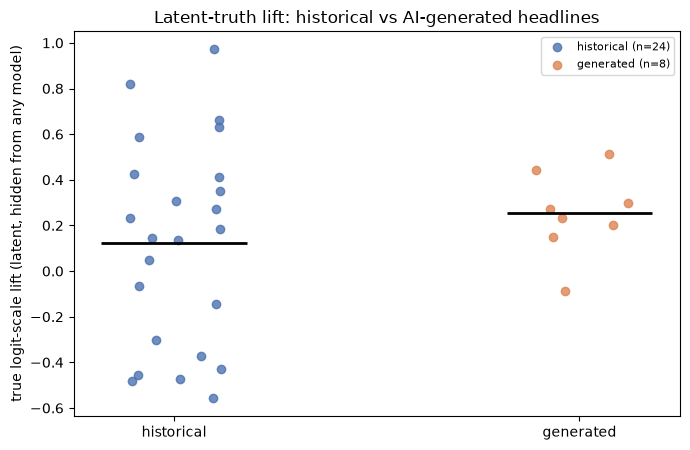

In [25]:
# Visualization only -- uses HISTORICAL_HEADLINES, generated_true_lifts, PALETTE
import matplotlib.pyplot as plt

hist_lifts = [row["true_logit_lift"] for row in HISTORICAL_HEADLINES]
rng_jitter = np.random.default_rng(SEED + 1)

fig, ax = plt.subplots(figsize=(7, 4.6))
x_hist = np.full(len(hist_lifts), 0) + rng_jitter.uniform(-0.12, 0.12, size=len(hist_lifts))
x_gen = np.full(len(generated_true_lifts), 1) + rng_jitter.uniform(-0.12, 0.12, size=len(generated_true_lifts))
ax.scatter(x_hist, hist_lifts, color=PALETTE["historical"], label=f"historical (n={len(hist_lifts)})", alpha=0.8)
ax.scatter(x_gen, generated_true_lifts, color=PALETTE["generated"], label=f"generated (n={len(generated_true_lifts)})", alpha=0.8)
for xc, ys in [(0, hist_lifts), (1, generated_true_lifts)]:
    ax.hlines(np.mean(ys), xc - 0.18, xc + 0.18, color="black", linewidth=2)
ax.set_xticks([0, 1]); ax.set_xticklabels(["historical", "generated"])
ax.set_ylabel("true logit-scale lift (latent, hidden from any model)")
ax.set_title("Latent-truth lift: historical vs AI-generated headlines")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## 6. Results summary + Recap

*Re-read before writing this: `tools/reread.py q1 q12`.*


In [26]:
print("=" * 78)
print("NOTEBOOK 2 -- RESULTS SUMMARY")
print("=" * 78)
print(f"[S1] population: n_total={n_total}, control signup rate (humans)={control_signup_rate_humans:.4f}, "
      f"bot share={bot_share:.4f}, true-new vs naive signup gap={(naive_signup_count/true_new_signup_count - 1)*100:.1f}%")
print(f"[S2] tracked funnel: visitor undercount ratio={visitor_undercount_ratio:.4f}, "
      f"conversion-rate overstatement={(tracked_conv_rate/true_conv_rate - 1)*100:.1f}%, "
      f"activation undercount ratio={activation_undercount_ratio:.4f}")
print(f"[S3] assignment: uniformity control share={share_ctrl:.5f}, covariate SMDs "
      f"({smd_prior_sessions:.4f}, {smd_fit_score:.4f}), true-assignment SRM p={srm_true['p_value']:.4f}, "
      f"tracked-exposure SRM p={srm_tracked['p_value']:.6f}")
print(f"[S4] naive baseline audit (N_REPS={N_REPS} each): E2 FPR daily-peek={e2_fpr_daily_peek:.4f} vs "
      f"single-look={e2_fpr_single_look:.4f}; E1 winner share={e1_winner_share:.3f} (median stop day "
      f"{e1_median_stop_day:.1f}); E3 wrongly-dropped share={e3_loser_share:.4f}; E4 true activated-users-per-visitor "
      f"change={e4_true_pct_change:.1f}% for ALL winners ({e4_winner_share*100:.1f}% of reps), only "
      f"{e4_winner_and_fell_conditional*100:.1f}% of which show the fall in-sample; E1 fixed-horizon n/arm="
      f"{n_per_arm_fixed:.0f} (~{implied_days_150} days at 150/arm/day)")
print(f"[S5] AI headline variants: {len(generated_variants)} generated, live DeepSeek calls this run="
      f"{LLM_STATS['live_calls']}, cache hits={LLM_STATS['cache_hits']}, ledger cost=${cost_off_peak:.6f} USD")
print("=" * 78)


NOTEBOOK 2 -- RESULTS SUMMARY
[S1] population: n_total=24296, control signup rate (humans)=0.0414, bot share=0.0504, true-new vs naive signup gap=7.8%
[S2] tracked funnel: visitor undercount ratio=0.8799, conversion-rate overstatement=22.5%, activation undercount ratio=0.9482
[S3] assignment: uniformity control share=0.50138, covariate SMDs (0.0054, 0.0001), true-assignment SRM p=0.3183, tracked-exposure SRM p=0.000000
[S4] naive baseline audit (N_REPS=2000 each): E2 FPR daily-peek=0.2840 vs single-look=0.0455; E1 winner share=0.285 (median stop day 7.0); E3 wrongly-dropped share=0.1380; E4 true activated-users-per-visitor change=-12.0% for ALL winners (32.9% of reps), only 27.2% of which show the fall in-sample; E1 fixed-horizon n/arm=61115 (~408 days at 150/arm/day)
[S5] AI headline variants: 8 generated, live DeepSeek calls this run=0, cache hits=3, ledger cost=$0.000108 USD


### What exists now vs. what Notebook 3 adds

This notebook built: a synthetic SaaS population with known latent truth (section 1); a realistic event-tracking gap between what's tracked and what's true (section 2); an honest, SRM-checkable hash-bucket assignment layer (section 3); a Monte-Carlo-scored audit of the founder's naive "peek daily, stop at first p<0.05" policy showing it is neither cleanly-alpha nor anytime-valid (section 4); and a smoke-tested, cost-tracked AI headline-variant generator plus historical "past human test" data with hidden latent truth (section 5).

Notebook 3 applies the three papers on top of exactly this API:
- **Screen** (Persson et al.): calibrate `score_headline_prompt` predictions against `HISTORICAL_HEADLINES`' observed rates, then run the surrogacy falsification test (Section 3.4.1) on OLS and a nonparametric calibrator before trusting any `generated_variants`. On the Upworthy data, q9 reports OLS failed this test (**"z = 3.8 SEs from zero"**) while Random Forest (1.6 SEs) and Gradient Boosted Trees (1.4 SEs) passed -- whether that pattern repeats on this notebook's 24 synthetic headlines is an open question NB3 will actually run, not assume.
- **Measure** (Lindon et al.): replace the naive z-test audited in section 4 with the regression-adjusted asymptotic-t confidence sequence (Eq. 22-23, Lemma 6.1), adjusting for `prior_sessions_30d`/`fit_score` as pre-treatment covariates, and re-run the E1-E4 audit to compare false-positive rate and stopping time against this notebook's own naive baseline.
- **Iterate** (Liang & Bojinov): run MAD (Definition 4) across the AI-generated (and falsification-passing) variants as a multi-armed bandit, with the Theorem 1 asymptotic confidence sequence in place of the naive per-arm z-tests.
- **Cost**: report the DeepSeek `USAGE_LEDGER`/`ledger_cost_usd` cost of screening every generated variant at the papers' recommended K, against the naive daily-peeking baseline's much larger implied sample-size cost from section 4.

### Limitations and open engineering choices

- **Which conversion definition to report** -- this notebook computes both the naive tracked signup count and the "true new signup" count (excluding bots, duplicates, existing-customer second workspaces); a real team has to pick one number to run experiments against and document why.
- **Bot filter** -- section 1/2 assume a fixed 70%-catch / 1%-false-flag heuristic; a real bot filter needs tuning against real traffic and will drift.
- **Activation window** -- 7 days is a design choice here; the real product needs a definition tied to actual usage data, and a policy for right-censored recent cohorts (section 2, [S2.4]).
- **Real analytics export** -- swap the synthetic population for a PostHog/GA4/Segment export with real pre-treatment covariates once one exists (see the dataset rationale in section 0).
- **The Next.js assignment middleware + exposure logging** -- `assign()` is a pure function here; wiring it into actual request middleware and logging the assignment probability per request (not a lossy client-side "exposure" event, per section 3's SRM demo) is unbuilt.
- **Guardrail metric choice** -- section 4's E4 result (shipped as a signup winner while activated users fall) only shows up because we happened to also track activation; a real guardrail-metric policy needs to be decided and enforced up front, not discovered after the fact.
- **Composition gaps from q12, quoted briefly**: *"No source in your notebook defines or proves a combined estimator that incorporates covariate regression adjustment into the Mixture Adaptive Design"*; *"the sources do NOT state or analyze using LLM predictions as pre-treatment covariates... for variance reduction"*; and *"No source states or proves a formal guarantee for a two-stage pipeline where an LLM screens out arms prior to a MAD trial"* (q12) -- so NB3's pipeline order (screen, then measure, then iterate) is a practical choice this project makes, not a guarantee any of the three papers gives it.
